<a href="https://colab.research.google.com/github/Shreya-1910/ArtificalMethodsCW/blob/main/cicids_pso_ga_with_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np

base_path = "/content/drive/MyDrive/CICIDS2017/preprocess/"

X = np.load(base_path + "x_full.npy")
y = np.load(base_path + "y_binary_full.npy")

print("Loaded:", X.shape, y.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: (2522362, 70) (2522362,)


In [15]:
from sklearn.model_selection import train_test_split

X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train_scaled.shape)
print("Test :", X_test_scaled.shape)

Train: (2017889, 70)
Test : (504473, 70)


In [16]:
!pip install pyswarms --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import json
import time
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

import pyswarms as ps

print(" All libraries ready!")

 All libraries ready!


In [17]:
print(" Data ready — proceeding with baseline model")

 Data ready — proceeding with baseline model


In [18]:
print("Creating validation split from training data...")
print(f"Original training size: {X_train_scaled.shape[0]:,} rows")

# Use 10% of training data as validation
# (keeping 90% for training because CICIDS2017 is large)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.10,
    random_state=42,
    stratify=y_train
)

print(f" Split complete:")
print(f"   Final train : {X_tr.shape[0]:,} rows")
print(f"   Validation  : {X_val.shape[0]:,} rows")
print(f"   Test        : {X_test_scaled.shape[0]:,} rows")
print(f"   Features    : {X_tr.shape[1]}")

Creating validation split from training data...
Original training size: 2,017,889 rows
 Split complete:
   Final train : 1,816,100 rows
   Validation  : 201,789 rows
   Test        : 504,473 rows
   Features    : 70


In [19]:
print("\n" + "=" * 55)
print("  BASELINE: RANDOM FOREST — ALL 70 FEATURES")
print("=" * 55)

# NOTE: CICIDS2017 has ~2M rows — we use a sample for speed
# Remove the sample_size limit if you have time/GPU runtime
SAMPLE_SIZE = 200_000   # ← increase to 500_000 or remove limit for full data

if X_tr.shape[0] > SAMPLE_SIZE:
    idx = np.random.choice(X_tr.shape[0], SAMPLE_SIZE, replace=False)
    X_tr_sample = X_tr[idx]
    y_tr_sample = y_tr.iloc[idx] if hasattr(y_tr, 'iloc') else y_tr[idx]
    print(f" Using {SAMPLE_SIZE:,} sample rows for speed (full={X_tr.shape[0]:,})")
else:
    X_tr_sample = X_tr
    y_tr_sample = y_tr
    print(f"Using full training set: {X_tr.shape[0]:,} rows")

# Train baseline RF with ALL features
start = time.time()
baseline_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,           # cap depth for large dataset speed
    random_state=42,
    n_jobs=-1,
    class_weight='balanced' # handles CICIDS2017 class imbalance (83% benign)
)
baseline_rf.fit(X_tr_sample, y_tr_sample)
train_time = time.time() - start

print(f"\n Baseline RF trained in {train_time:.1f}s")
print(f"   Features used: {X_tr_sample.shape[1]} (ALL features)")



  BASELINE: RANDOM FOREST — ALL 70 FEATURES
 Using 200,000 sample rows for speed (full=1,816,100)

 Baseline RF trained in 73.1s
   Features used: 70 (ALL features)


In [20]:
print("\n" + "=" * 55)
print("  VALIDATE ON VALIDATION SET")
print("=" * 55)

y_val_pred  = baseline_rf.predict(X_val)
y_val_proba = baseline_rf.predict_proba(X_val)[:, 1]

print(f" Predicted {len(y_val_pred):,} validation samples")
print(f"   Predicted attacks : {y_val_pred.sum():,}")
print(f"   Actual attacks    : {(y_val == 1).sum():,}")



  VALIDATE ON VALIDATION SET
 Predicted 201,789 validation samples
   Predicted attacks : 34,015
   Actual attacks    : 34,070


In [21]:
print("\n" + "=" * 55)
print("  BASELINE PERFORMANCE METRICS (Validation Set)")
print("=" * 55)

baseline_val_acc  = accuracy_score(y_val, y_val_pred)
baseline_val_prec = precision_score(y_val, y_val_pred, average='weighted', zero_division=0)
baseline_val_rec  = recall_score(y_val, y_val_pred, average='weighted', zero_division=0)
baseline_val_f1   = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)
baseline_val_auc  = roc_auc_score(y_val, y_val_proba)

print(f"\n  Accuracy  : {baseline_val_acc:.4f}")
print(f"  Precision : {baseline_val_prec:.4f}")
print(f"  Recall    : {baseline_val_rec:.4f}")
print(f"  F1-Score  : {baseline_val_f1:.4f}")
print(f"  ROC-AUC   : {baseline_val_auc:.4f}")

print("\n Full Classification Report (Validation):")
print(classification_report(y_val, y_val_pred,
      target_names=["BENIGN (0)", "ATTACK (1)"], zero_division=0))



  BASELINE PERFORMANCE METRICS (Validation Set)

  Accuracy  : 0.9986
  Precision : 0.9986
  Recall    : 0.9986
  F1-Score  : 0.9986
  ROC-AUC   : 0.9999

 Full Classification Report (Validation):
              precision    recall  f1-score   support

  BENIGN (0)       1.00      1.00      1.00    167719
  ATTACK (1)       1.00      1.00      1.00     34070

    accuracy                           1.00    201789
   macro avg       1.00      1.00      1.00    201789
weighted avg       1.00      1.00      1.00    201789




  CONFUSION MATRIX (Validation Set)

Raw matrix:
[[167605    114]
 [   169  33901]]

  TN (Correctly BENIGN) : 167,605
  FP (False Alarm)      : 114  ← BENIGN flagged as attack
  FN (Missed Attack)    : 169  ← Attack missed  
  TP (Correctly ATTACK) : 33,901


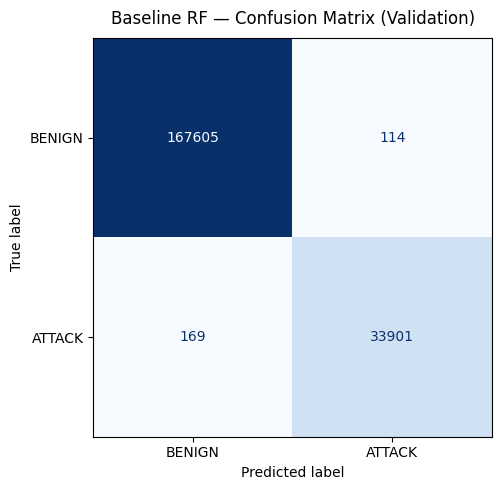

Saved: confusion_matrix_baseline.png


In [22]:
print("\n" + "=" * 55)
print("  CONFUSION MATRIX (Validation Set)")
print("=" * 55)

cm_val = confusion_matrix(y_val, y_val_pred)
print("\nRaw matrix:")
print(cm_val)
print(f"\n  TN (Correctly BENIGN) : {cm_val[0,0]:,}")
print(f"  FP (False Alarm)      : {cm_val[0,1]:,}  ← BENIGN flagged as attack")
print(f"  FN (Missed Attack)    : {cm_val[1,0]:,}  ← Attack missed  ")
print(f"  TP (Correctly ATTACK) : {cm_val[1,1]:,}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_val,
                       display_labels=["BENIGN", "ATTACK"]).plot(
    cmap='Blues', ax=ax, colorbar=False)
ax.set_title("Baseline RF — Confusion Matrix (Validation)", fontsize=12, pad=10)
plt.tight_layout()
plt.savefig("confusion_matrix_baseline.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix_baseline.png")


In [23]:
print("\n" + "=" * 55)
print("  FINAL TEST EVALUATION (Unseen Test Set)")
print("=" * 55)

y_test_pred  = baseline_rf.predict(X_test_scaled)
y_test_proba = baseline_rf.predict_proba(X_test_scaled)[:, 1]

baseline_test_metrics = {
    "model":      "Random Forest (Baseline — All 70 Features)",
    "accuracy":   float(accuracy_score(y_test, y_test_pred)),
    "precision":  float(precision_score(y_test, y_test_pred, average='weighted', zero_division=0)),
    "recall":     float(recall_score(y_test, y_test_pred, average='weighted', zero_division=0)),
    "f1":         float(f1_score(y_test, y_test_pred, average='weighted', zero_division=0)),
    "roc_auc":    float(roc_auc_score(y_test, y_test_proba)),
    "n_features": int(X_test_scaled.shape[1])
}

print(f"\n  Test Accuracy  : {baseline_test_metrics['accuracy']:.4f}")
print(f"  Test Precision : {baseline_test_metrics['precision']:.4f}")
print(f"  Test Recall    : {baseline_test_metrics['recall']:.4f}")
print(f"  Test F1-Score  : {baseline_test_metrics['f1']:.4f}")
print(f"  Test ROC-AUC   : {baseline_test_metrics['roc_auc']:.4f}")
print(f"\n BASELINE F1 TO BEAT: {baseline_test_metrics['f1']:.4f}")


  FINAL TEST EVALUATION (Unseen Test Set)

  Test Accuracy  : 0.9985
  Test Precision : 0.9985
  Test Recall    : 0.9985
  Test F1-Score  : 0.9985
  Test ROC-AUC   : 0.9999

 BASELINE F1 TO BEAT: 0.9985


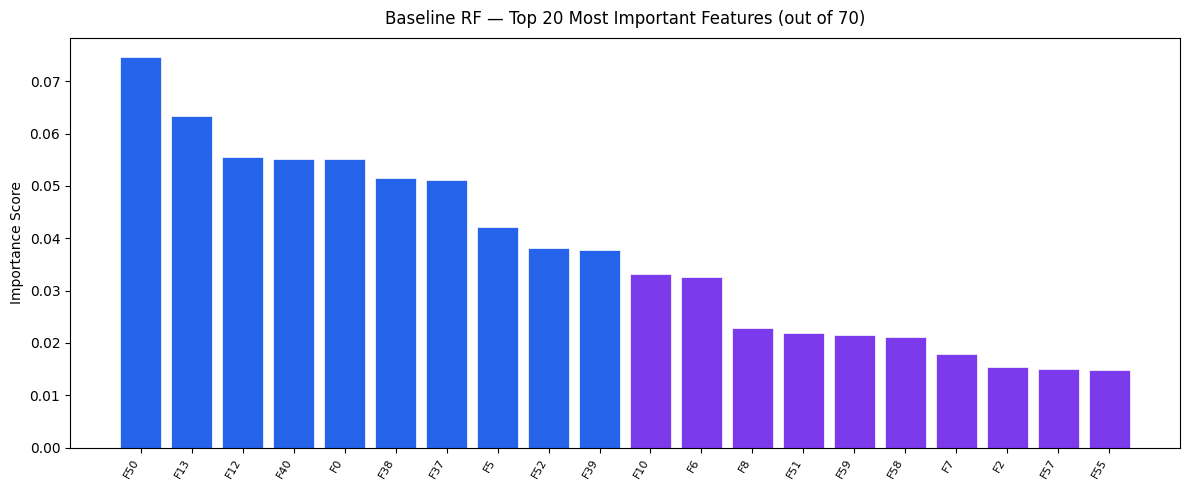

 Saved: feature_importance_baseline.png

Top 10 most important features:
   1. F50                                      0.0746
   2. F13                                      0.0634
   3. F12                                      0.0554
   4. F40                                      0.0551
   5. F0                                       0.0551
   6. F38                                      0.0515
   7. F37                                      0.0511
   8. F5                                       0.0421
   9. F52                                      0.0381
  10. F39                                      0.0378


In [24]:
importances = baseline_rf.feature_importances_
feat_names  = feature_cols if 'feature_cols' in dir() else [f"F{i}" for i in range(len(importances))]

# Top 20 features
top_n = 20
indices = np.argsort(importances)[::-1][:top_n]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(top_n),
       importances[indices],
       color=['#2563eb' if i < 10 else '#7c3aed' for i in range(top_n)],
       edgecolor='white', linewidth=0.5)
ax.set_xticks(range(top_n))
ax.set_xticklabels([feat_names[i] for i in indices], rotation=60, ha='right', fontsize=8)
ax.set_title(f"Baseline RF — Top {top_n} Most Important Features (out of {len(importances)})",
             fontsize=12, pad=10)
ax.set_ylabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance_baseline.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: feature_importance_baseline.png")

# Show top 10 feature names
print("\nTop 10 most important features:")
for rank, i in enumerate(indices[:10], 1):
    print(f"  {rank:2}. {feat_names[i]:<40} {importances[i]:.4f}")


In [25]:
with open('baseline_rf_cicids.pkl', 'wb') as f:
    pickle.dump(baseline_rf, f)

with open('baseline_metrics.json', 'w') as f:
    json.dump(baseline_test_metrics, f, indent=2)

print(" baseline_rf_cicids.pkl  → saved")
print(" baseline_metrics.json  → saved")
print(f"\n BASELINE RECORDED:")
print(f"   Model    : {baseline_test_metrics['model']}")
print(f"   Features : {baseline_test_metrics['n_features']}")
print(f"   F1-Score : {baseline_test_metrics['f1']:.4f}  ← PSO/GA must beat this!")


 baseline_rf_cicids.pkl  → saved
 baseline_metrics.json  → saved

 BASELINE RECORDED:
   Model    : Random Forest (Baseline — All 70 Features)
   Features : 70
   F1-Score : 0.9985  ← PSO/GA must beat this!


In [26]:
PSO_SAMPLE = 50_000   # rows used per fitness evaluation
                      # increase if you have more time

# Subsample for PSO/GA fitness evaluation
idx_pso = np.random.choice(X_tr.shape[0], min(PSO_SAMPLE, X_tr.shape[0]), replace=False)
X_pso_train = X_tr[idx_pso]
y_pso_train = y_tr.iloc[idx_pso] if hasattr(y_tr, 'iloc') else y_tr[idx_pso]

# Smaller validation sample for speed
idx_val = np.random.choice(X_val.shape[0], min(20_000, X_val.shape[0]), replace=False)
X_pso_val = X_val[idx_val]
y_pso_val = y_val.iloc[idx_val] if hasattr(y_val, 'iloc') else y_val[idx_val]

n_features = X_tr.shape[1]
print(f"PSO/GA setup:")
print(f"  Total features     : {n_features}")
print(f"  Train sample size  : {X_pso_train.shape[0]:,}")
print(f"  Val sample size    : {X_pso_val.shape[0]:,}")
print(f"\n  Note: Each PSO/GA fitness call trains a RF — this takes time.")
print(f"   ~30 particles × 50 iters = ~1500 RF trains for PSO")


def pso_fitness(particles):
    """
    PSO fitness function.
    Each particle = 70 floats. Value > 0.5 → use that feature.
    PSO minimises, so we return -F1.
    """
    scores = []
    for particle in particles:
        mask = particle > 0.5
        if mask.sum() == 0:
            scores.append(1.0)
            continue

        rf = RandomForestClassifier(
            n_estimators=30,       # small for speed inside PSO
            max_depth=10,
            random_state=42,
            n_jobs=-1,
            class_weight='balanced'
        )
        rf.fit(X_pso_train[:, mask], y_pso_train)
        y_pred = rf.predict(X_pso_val[:, mask])
        f1 = f1_score(y_pso_val, y_pred, average='weighted', zero_division=0)

        # Small penalty per feature (rewards fewer features)
        penalty = 0.0005 * mask.sum()
        scores.append(-f1 + penalty)

    return np.array(scores)

print("\n PSO fitness function defined")



PSO/GA setup:
  Total features     : 70
  Train sample size  : 50,000
  Val sample size    : 20,000

  Note: Each PSO/GA fitness call trains a RF — this takes time.
   ~30 particles × 50 iters = ~1500 RF trains for PSO

 PSO fitness function defined


In [27]:
pso_options = {'c1': 1.5, 'c2': 1.5, 'w': 0.7}
bounds = (np.zeros(n_features), np.ones(n_features))

print(f"Running PSO: 30 particles × 50 iterations on {n_features} features")
print("(This will take several minutes on CICIDS2017...)\n")

optimizer = ps.single.GlobalBestPSO(
    n_particles=30,
    dimensions=n_features,
    options=pso_options,
    bounds=bounds
)

start_pso = time.time()
best_cost_pso, best_pos_pso = optimizer.optimize(pso_fitness, iters=50, verbose=True)
pso_time = time.time() - start_pso

print(f"\n PSO done in {pso_time/60:.1f} minutes")



2026-04-17 15:01:09,318 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.7}


Running PSO: 30 particles × 50 iterations on 70 features
(This will take several minutes on CICIDS2017...)



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=-0.988
2026-04-17 15:46:37,184 - pyswarms.single.global_best - INFO - Optimization finished | best cost: -0.9876976338730394, best pos: [0.77268141 0.4075358  0.43152686 0.46075253 0.10566851 0.4009394
 0.22112231 0.5208642  0.10212445 0.4504391  0.4386414  0.42623028
 0.30431295 0.36535925 0.53062003 0.09711417 0.13785752 0.44586644
 0.39490025 0.50372106 0.38770007 0.36355379 0.78078985 0.41193873
 0.82150895 0.47285698 0.5698882  0.01350798 0.5684259  0.45054894
 0.60836391 0.66809886 0.21437608 0.76254311 0.28643078 0.38317741
 0.64805766 0.46038552 0.23008173 0.49238035 0.49938511 0.48812586
 0.05961581 0.20801471 0.13552212 0.39109389 0.4246457  0.21148262
 0.48326354 0.43552018 0.58958808 0.67146982 0.61670086 0.64206464
 0.57623271 0.79704015 0.49389195 0.97071426 0.27390645 0.22769369
 0.14582192 0.23889083 0.41267508 0.36859235 0.42903912 0.22189694
 0.3329054  0.42326407 0.44476936 0.40563925]



 PSO done in 45.5 minutes


In [28]:
pso_mask     = best_pos_pso > 0.5
pso_feat_idx = np.where(pso_mask)[0]
pso_n_feats  = int(pso_mask.sum())
feat_names_list = feature_cols if 'feature_cols' in dir() else [f"F{i}" for i in range(n_features)]

print(f"\nPSO selected {pso_n_feats} / {n_features} features:")
print(f"  Kept    : {[feat_names_list[i] for i in pso_feat_idx]}")
print(f"  Dropped : {[feat_names_list[i] for i in range(n_features) if i not in pso_feat_idx]}")

# Train final PSO model on FULL training sample
pso_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
pso_rf.fit(X_tr_sample[:, pso_mask], y_tr_sample)

y_test_pred_pso  = pso_rf.predict(X_test_scaled[:, pso_mask])
y_test_proba_pso = pso_rf.predict_proba(X_test_scaled[:, pso_mask])[:, 1]

pso_metrics = {
    "model":      "Random Forest + PSO",
    "accuracy":   float(accuracy_score(y_test, y_test_pred_pso)),
    "precision":  float(precision_score(y_test, y_test_pred_pso, average='weighted', zero_division=0)),
    "recall":     float(recall_score(y_test, y_test_pred_pso, average='weighted', zero_division=0)),
    "f1":         float(f1_score(y_test, y_test_pred_pso, average='weighted', zero_division=0)),
    "roc_auc":    float(roc_auc_score(y_test, y_test_proba_pso)),
    "n_features": pso_n_feats
}

print(f"\n PSO Model — Test Results:")
print(f"  Accuracy  : {pso_metrics['accuracy']:.4f}")
print(f"  Precision : {pso_metrics['precision']:.4f}")
print(f"  Recall    : {pso_metrics['recall']:.4f}")
print(f"  F1-Score  : {pso_metrics['f1']:.4f}")
print(f"  ROC-AUC   : {pso_metrics['roc_auc']:.4f}")
print(f"  Features  : {pso_n_feats} (was {n_features})")

diff = pso_metrics['f1'] - baseline_test_metrics['f1']
if diff > 0:
    print(f"\n PSO BEAT BASELINE by +{diff:.4f} F1 using {n_features - pso_n_feats} fewer features!")
else:
    print(f"\n PSO vs baseline: Δ F1 = {diff:.4f}")




PSO selected 19 / 70 features:
  Kept    : ['F0', 'F7', 'F14', 'F19', 'F22', 'F24', 'F26', 'F28', 'F30', 'F31', 'F33', 'F36', 'F50', 'F51', 'F52', 'F53', 'F54', 'F55', 'F57']
  Dropped : ['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F8', 'F9', 'F10', 'F11', 'F12', 'F13', 'F15', 'F16', 'F17', 'F18', 'F20', 'F21', 'F23', 'F25', 'F27', 'F29', 'F32', 'F34', 'F35', 'F37', 'F38', 'F39', 'F40', 'F41', 'F42', 'F43', 'F44', 'F45', 'F46', 'F47', 'F48', 'F49', 'F56', 'F58', 'F59', 'F60', 'F61', 'F62', 'F63', 'F64', 'F65', 'F66', 'F67', 'F68', 'F69']

 PSO Model — Test Results:
  Accuracy  : 0.9977
  Precision : 0.9977
  Recall    : 0.9977
  F1-Score  : 0.9977
  ROC-AUC   : 0.9999
  Features  : 19 (was 70)

 PSO vs baseline: Δ F1 = -0.0008


In [29]:
def ga_fitness(chromosome):
    """chromosome: binary array of length 70. 1=use, 0=skip."""
    mask = chromosome == 1
    if mask.sum() == 0:
        return 0.0
    rf = RandomForestClassifier(
        n_estimators=30,
        max_depth=10,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    )
    rf.fit(X_pso_train[:, mask], y_pso_train)
    y_pred = rf.predict(X_pso_val[:, mask])
    return float(f1_score(y_pso_val, y_pred, average='weighted', zero_division=0))


def tournament_selection(population, scores, k=3):
    idx = np.random.choice(len(population), k, replace=False)
    return population[idx[np.argmax(scores[idx])]].copy()


def crossover(p1, p2, rate=0.9):
    if np.random.rand() < rate:
        pt = np.random.randint(1, len(p1))
        return (np.concatenate([p1[:pt], p2[pt:]]),
                np.concatenate([p2[:pt], p1[pt:]]))
    return p1.copy(), p2.copy()


def mutate(chrom, rate=0.05):
    flip = np.random.rand(len(chrom)) < rate
    chrom[flip] = 1 - chrom[flip]
    return chrom

print(" GA functions defined")


 GA functions defined


In [30]:
GA_POP       = 30
GA_GENS      = 40
GA_MUTATION  = 0.05
GA_ELITES    = 2

print(f"Running GA: {GA_POP} chromosomes × {GA_GENS} generations")
print(f"Each chromosome = {n_features} bits (1=use feature, 0=drop)\n")

population = np.random.randint(0, 2, (GA_POP, n_features))
best_per_gen = []
avg_per_gen  = []

start_ga = time.time()

for gen in range(GA_GENS):
    scores = np.array([ga_fitness(c) for c in population])
    best_idx = np.argmax(scores)

    best_per_gen.append(scores[best_idx])
    avg_per_gen.append(scores.mean())

    print(f"  Gen {gen+1:02d}/{GA_GENS} | "
          f"Best F1: {scores[best_idx]:.4f} | "
          f"Avg F1: {scores.mean():.4f} | "
          f"Feats: {int(population[best_idx].sum())}")

    # Elitism
    top_idx = np.argsort(scores)[::-1][:GA_ELITES]
    new_pop = [population[i].copy() for i in top_idx]

    # Breed rest
    while len(new_pop) < GA_POP:
        p1 = tournament_selection(population, scores)
        p2 = tournament_selection(population, scores)
        c1, c2 = crossover(p1, p2)
        new_pop.append(mutate(c1, GA_MUTATION))
        if len(new_pop) < GA_POP:
            new_pop.append(mutate(c2, GA_MUTATION))

    population = np.array(new_pop)

ga_time = time.time() - start_ga
print(f"\n GA done in {ga_time/60:.1f} minutes")



Running GA: 30 chromosomes × 40 generations
Each chromosome = 70 bits (1=use feature, 0=drop)

  Gen 01/40 | Best F1: 0.9977 | Avg F1: 0.9966 | Feats: 36
  Gen 02/40 | Best F1: 0.9979 | Avg F1: 0.9970 | Feats: 37
  Gen 03/40 | Best F1: 0.9979 | Avg F1: 0.9974 | Feats: 37
  Gen 04/40 | Best F1: 0.9979 | Avg F1: 0.9976 | Feats: 37
  Gen 05/40 | Best F1: 0.9981 | Avg F1: 0.9978 | Feats: 39
  Gen 06/40 | Best F1: 0.9981 | Avg F1: 0.9978 | Feats: 39
  Gen 07/40 | Best F1: 0.9981 | Avg F1: 0.9978 | Feats: 39
  Gen 08/40 | Best F1: 0.9981 | Avg F1: 0.9977 | Feats: 39
  Gen 09/40 | Best F1: 0.9981 | Avg F1: 0.9978 | Feats: 39
  Gen 10/40 | Best F1: 0.9982 | Avg F1: 0.9978 | Feats: 38
  Gen 11/40 | Best F1: 0.9982 | Avg F1: 0.9978 | Feats: 38
  Gen 12/40 | Best F1: 0.9982 | Avg F1: 0.9977 | Feats: 37
  Gen 13/40 | Best F1: 0.9982 | Avg F1: 0.9978 | Feats: 38
  Gen 14/40 | Best F1: 0.9982 | Avg F1: 0.9978 | Feats: 37
  Gen 15/40 | Best F1: 0.9982 | Avg F1: 0.9979 | Feats: 38
  Gen 16/40 | Best F

In [31]:
final_scores  = np.array([ga_fitness(c) for c in population])
best_chrom    = population[np.argmax(final_scores)]
ga_mask       = best_chrom == 1
ga_feat_idx   = np.where(ga_mask)[0]
ga_n_feats    = int(ga_mask.sum())

print(f"\nGA selected {ga_n_feats} / {n_features} features:")
print(f"  Kept    : {[feat_names_list[i] for i in ga_feat_idx]}")
print(f"  Dropped : {[feat_names_list[i] for i in range(n_features) if i not in ga_feat_idx]}")

# Final model with GA features
ga_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
ga_rf.fit(X_tr_sample[:, ga_mask], y_tr_sample)

y_test_pred_ga  = ga_rf.predict(X_test_scaled[:, ga_mask])
y_test_proba_ga = ga_rf.predict_proba(X_test_scaled[:, ga_mask])[:, 1]

ga_metrics = {
    "model":      "Random Forest + GA",
    "accuracy":   float(accuracy_score(y_test, y_test_pred_ga)),
    "precision":  float(precision_score(y_test, y_test_pred_ga, average='weighted', zero_division=0)),
    "recall":     float(recall_score(y_test, y_test_pred_ga, average='weighted', zero_division=0)),
    "f1":         float(f1_score(y_test, y_test_pred_ga, average='weighted', zero_division=0)),
    "roc_auc":    float(roc_auc_score(y_test, y_test_proba_ga)),
    "n_features": ga_n_feats
}

print(f"\n GA Model — Test Results:")
print(f"  Accuracy  : {ga_metrics['accuracy']:.4f}")
print(f"  Precision : {ga_metrics['precision']:.4f}")
print(f"  Recall    : {ga_metrics['recall']:.4f}")
print(f"  F1-Score  : {ga_metrics['f1']:.4f}")
print(f"  ROC-AUC   : {ga_metrics['roc_auc']:.4f}")
print(f"  Features  : {ga_n_feats} (was {n_features})")

diff_ga = ga_metrics['f1'] - baseline_test_metrics['f1']
if diff_ga > 0:
    print(f"\n GA BEAT BASELINE by +{diff_ga:.4f} F1 using {n_features - ga_n_feats} fewer features!")
else:
    print(f"\n GA vs baseline: Δ F1 = {diff_ga:.4f}")



GA selected 40 / 70 features:
  Kept    : ['F0', 'F1', 'F2', 'F3', 'F5', 'F6', 'F10', 'F14', 'F19', 'F20', 'F21', 'F22', 'F23', 'F24', 'F26', 'F27', 'F28', 'F29', 'F30', 'F32', 'F33', 'F34', 'F35', 'F36', 'F41', 'F42', 'F43', 'F45', 'F46', 'F53', 'F54', 'F55', 'F56', 'F58', 'F59', 'F61', 'F62', 'F64', 'F67', 'F69']
  Dropped : ['F4', 'F7', 'F8', 'F9', 'F11', 'F12', 'F13', 'F15', 'F16', 'F17', 'F18', 'F25', 'F31', 'F37', 'F38', 'F39', 'F40', 'F44', 'F47', 'F48', 'F49', 'F50', 'F51', 'F52', 'F57', 'F60', 'F63', 'F65', 'F66', 'F68']

 GA Model — Test Results:
  Accuracy  : 0.9987
  Precision : 0.9987
  Recall    : 0.9987
  F1-Score  : 0.9987
  ROC-AUC   : 0.9999
  Features  : 40 (was 70)

 GA BEAT BASELINE by +0.0002 F1 using 30 fewer features!


In [32]:
all_results = [baseline_test_metrics, pso_metrics, ga_metrics]

print("\n" + "=" * 78)
print("  FINAL COMPARISON — CICIDS2017 INTRUSION DETECTION")
print("=" * 78)
print(f"\n{'Model':<38} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7} {'Feats':>6}")
print("-" * 78)

for r in all_results:
    marker = "★" if r == max(all_results, key=lambda x: x['f1']) else ""
    print(f"{r['model']:<38}"
          f"{r['accuracy']:>7.4f}"
          f"{r['precision']:>7.4f}"
          f"{r['recall']:>7.4f}"
          f"{r['f1']:>7.4f}"
          f"{r['roc_auc']:>7.4f}"
          f"{r['n_features']:>6}{marker}")

print("-" * 78)
best = max(all_results, key=lambda x: x['f1'])
print(f"\n Best model: {best['model']}  |  F1={best['f1']:.4f}  |  Features={best['n_features']}")



  FINAL COMPARISON — CICIDS2017 INTRUSION DETECTION

Model                                      Acc    Prec     Rec      F1     AUC  Feats
------------------------------------------------------------------------------
Random Forest (Baseline — All 70 Features) 0.9985 0.9985 0.9985 0.9985 0.9999    70
Random Forest + PSO                    0.9977 0.9977 0.9977 0.9977 0.9999    19
Random Forest + GA                     0.9987 0.9987 0.9987 0.9987 0.9999    40★
------------------------------------------------------------------------------

 Best model: Random Forest + GA  |  F1=0.9987  |  Features=40


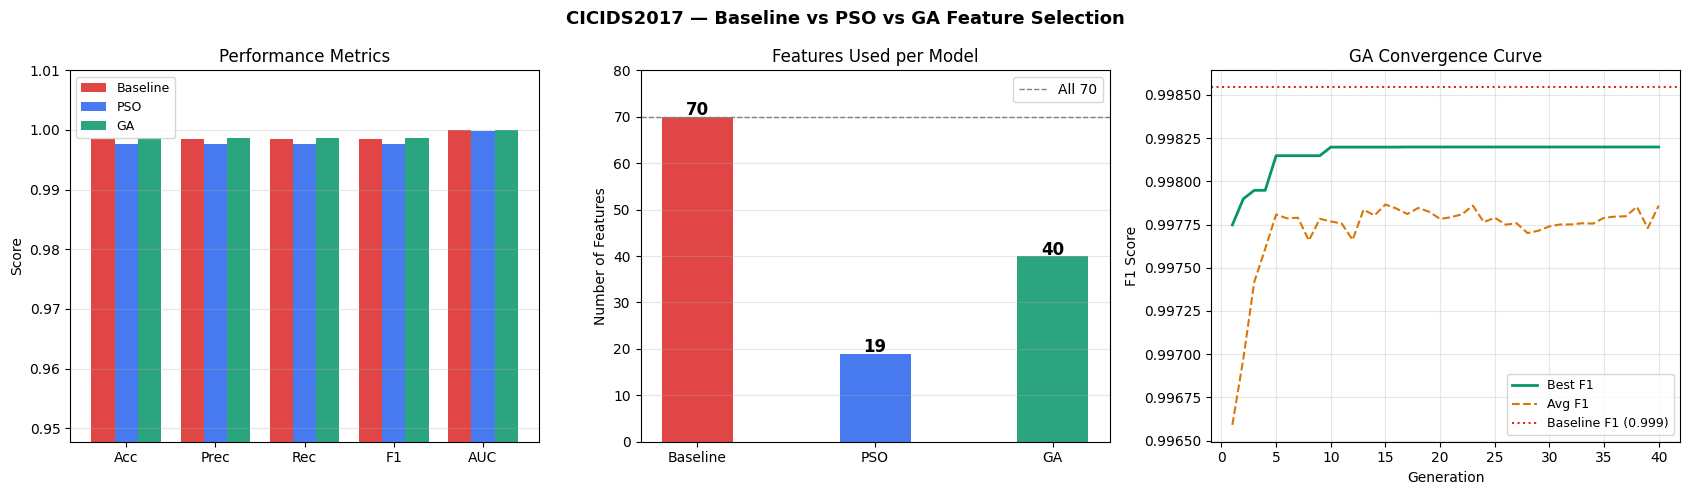

 Saved: final_comparison_cicids.png


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("CICIDS2017 — Baseline vs PSO vs GA Feature Selection",
             fontsize=13, fontweight='bold')

# Plot 1: Metrics grouped bar
ax1 = axes[0]
metric_keys  = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_label = ['Acc', 'Prec', 'Rec', 'F1', 'AUC']
x_pos   = np.arange(len(metric_keys))
w       = 0.26
colors  = ['#dc2626', '#2563eb', '#059669']
m_labels = ['Baseline', 'PSO', 'GA']
for i, (r, c, lbl) in enumerate(zip(all_results, colors, m_labels)):
    ax1.bar(x_pos + i*w, [r[k] for k in metric_keys], w,
            label=lbl, color=c, alpha=0.85)
ax1.set_xticks(x_pos + w)
ax1.set_xticklabels(metric_label)
ax1.set_ylim(min(r['f1'] for r in all_results) - 0.05, 1.01)
ax1.set_title("Performance Metrics")
ax1.set_ylabel("Score")
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Features used
ax2 = axes[1]
feat_counts = [r['n_features'] for r in all_results]
bars = ax2.bar(m_labels, feat_counts, color=colors, alpha=0.85, width=0.4)
for bar, cnt in zip(bars, feat_counts):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3, str(cnt),
             ha='center', fontweight='bold', fontsize=12)
ax2.axhline(n_features, color='grey', linestyle='--', linewidth=1, label=f'All {n_features}')
ax2.set_ylim(0, n_features + 10)
ax2.set_title("Features Used per Model")
ax2.set_ylabel("Number of Features")
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Plot 3: GA convergence
ax3 = axes[2]
gens = range(1, GA_GENS + 1)
ax3.plot(gens, best_per_gen, color='#059669', linewidth=2, label='Best F1')
ax3.plot(gens, avg_per_gen,  color='#d97706', linewidth=1.5, linestyle='--', label='Avg F1')
ax3.axhline(baseline_test_metrics['f1'], color='#dc2626',
            linestyle=':', linewidth=1.5, label=f"Baseline F1 ({baseline_test_metrics['f1']:.3f})")
ax3.set_xlabel("Generation")
ax3.set_ylabel("F1 Score")
ax3.set_title("GA Convergence Curve")
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("final_comparison_cicids.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: final_comparison_cicids.png")


In [34]:
save_path = '/content/drive/MyDrive/AIMcw/results/'
os.makedirs(save_path, exist_ok=True)

# Save models
with open(f'{save_path}baseline_rf.pkl', 'wb') as f: pickle.dump(baseline_rf, f)
with open(f'{save_path}pso_rf.pkl',      'wb') as f: pickle.dump(pso_rf, f)
with open(f'{save_path}ga_rf.pkl',       'wb') as f: pickle.dump(ga_rf, f)

# Save all metrics + selected features
final_save = {
    "baseline":          baseline_test_metrics,
    "pso":               {**pso_metrics,
                          "selected_feature_names": [feat_names_list[i] for i in pso_feat_idx],
                          "selected_feature_indices": pso_feat_idx.tolist()},
    "ga":                {**ga_metrics,
                          "selected_feature_names": [feat_names_list[i] for i in ga_feat_idx],
                          "selected_feature_indices": ga_feat_idx.tolist()},
    "best_model":        best['model']
}

with open(f'{save_path}all_results.json', 'w') as f:
    json.dump(final_save, f, indent=2)

print("All models + results saved to Drive!")
print(f"\n REPORT TABLE (copy this):\n")
print(f"{'Model':<40} {'Accuracy':>9} {'Precision':>9} {'Recall':>9} {'F1-Score':>9} {'ROC-AUC':>8} {'Features':>8}")
print("-" * 97)
for r in all_results:
    print(f"{r['model']:<40}"
          f"{r['accuracy']:>9.4f}"
          f"{r['precision']:>9.4f}"
          f"{r['recall']:>9.4f}"
          f"{r['f1']:>9.4f}"
          f"{r['roc_auc']:>8.4f}"
          f"{r['n_features']:>8}")
print("-" * 97)

All models + results saved to Drive!

 REPORT TABLE (copy this):

Model                                     Accuracy Precision    Recall  F1-Score  ROC-AUC Features
-------------------------------------------------------------------------------------------------
Random Forest (Baseline — All 70 Features)   0.9985   0.9985   0.9985   0.9985  0.9999      70
Random Forest + PSO                        0.9977   0.9977   0.9977   0.9977  0.9999      19
Random Forest + GA                         0.9987   0.9987   0.9987   0.9987  0.9999      40
-------------------------------------------------------------------------------------------------
